# Konvolucione neuronske mreže za klasifikaciju CIFAR-10
# Laboratorijska vježba 6: Neuronske mreže (4/4)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.optimizers import SGD

# a) Učitati CIFAR-10 skup podataka i ispisati oblik trening i test podataka i labela


In [3]:
(trainX, trainy), (testX, testy) = cifar10.load_data()
print('Oblik training podataka: ', trainX.shape)
print('Oblik training labela: ', trainy.shape)
print('Oblik test podataka: ', testX.shape)
print('Oblik test labela: ', testy.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Oblik training podataka:  (50000, 32, 32, 3)
Oblik training labela:  (50000, 1)
Oblik test podataka:  (10000, 32, 32, 3)
Oblik test labela:  (10000, 1)


# b) Iscrtati prvih 9 slika iz skupa podataka

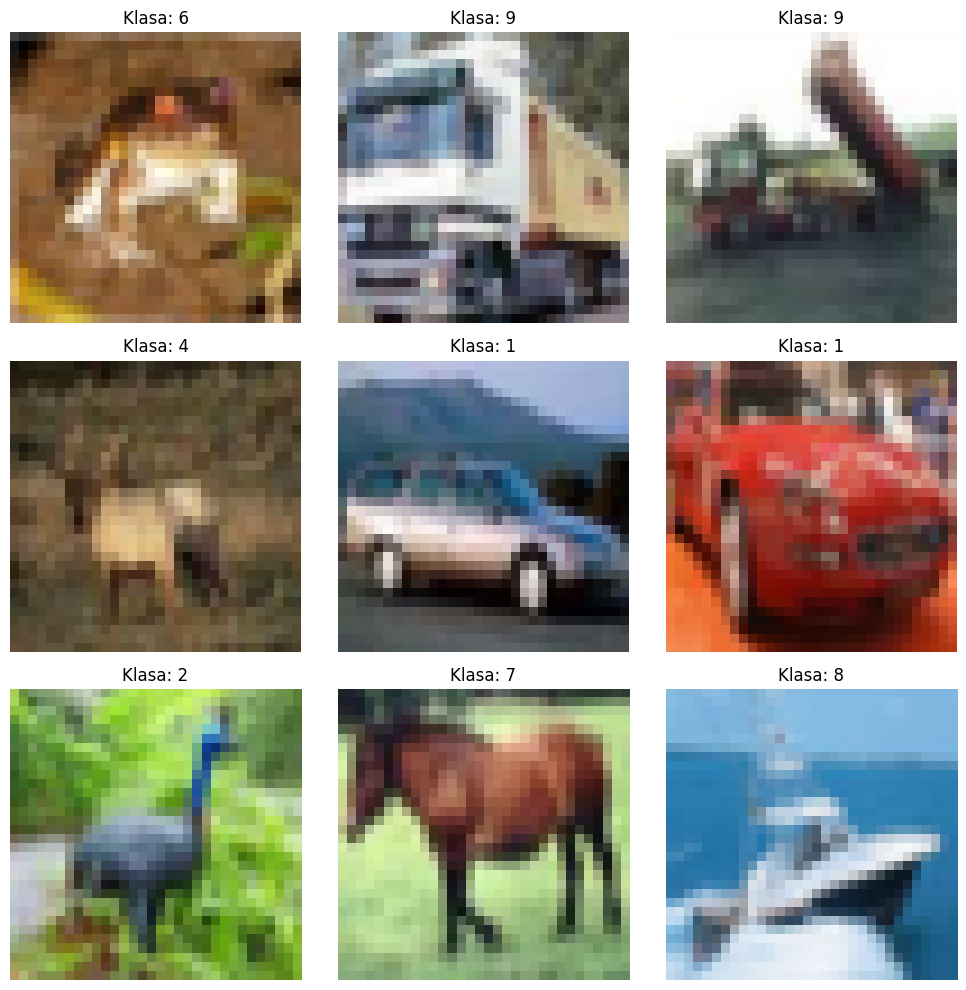

In [4]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(trainX[i])
    plt.title(f'Klasa: {trainy[i][0]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Nazivi klasa za referencu


In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Klase u CIFAR-10:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Klase u CIFAR-10:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


# c) Pripremiti podatke za treniranje
# Pretvoriti labele u one-hot encoding

In [6]:
trainY = to_categorical(trainy, 10)
testY = to_categorical(testy, 10)

# Pretvoriti podatke u float32 i skalirati na opseg [0, 1]
trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0

# d) i e) Definisati pomoćnu funkciju za kreiranje modela

In [7]:
def define_model():
    model = Sequential()

    # Prvi blok konvolucionih slojeva
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    # Drugi blok konvolucionih slojeva
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    # Pretvaranje 2D podataka u 1D
    model.add(Flatten())

    # Potpuno povezani slojevi
    model.add(Dense(128, activation='relu'))

    # Izlazni sloj
    model.add(Dense(10, activation='softmax'))

    # Kompajliranje modela
    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Kreiranje baseline modela


In [8]:
model = define_model()
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

# f) Treniranje i evaluacija modela


In [9]:
history = model.fit(
    trainX, trainY,
    epochs=15,
    batch_size=64,
    validation_data=(testX, testY),
    verbose=1
)

# Evaluacija modela
_, acc = model.evaluate(testX, testY, verbose=0)
print('Tačnost baseline modela: %.3f' % (acc * 100.0))

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.1513 - loss: 2.2402 - val_accuracy: 0.3035 - val_loss: 1.9311
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3461 - loss: 1.8361 - val_accuracy: 0.4020 - val_loss: 1.6839
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4323 - loss: 1.5971 - val_accuracy: 0.4856 - val_loss: 1.4324
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4903 - loss: 1.4295 - val_accuracy: 0.5157 - val_loss: 1.3778
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5289 - loss: 1.3238 - val_accuracy: 0.5520 - val_loss: 1.2720
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5600 - loss: 1.2452 - val_accuracy: 0.5707 - val_loss: 1.2079
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5854 - loss: 1.1793 - val_accuracy: 0.5858 - val_loss: 1.1701
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6120 - loss: 1.1051 - val_accuracy:

# g) Plot ponašanja tačnosti i gubitka kroz epohe


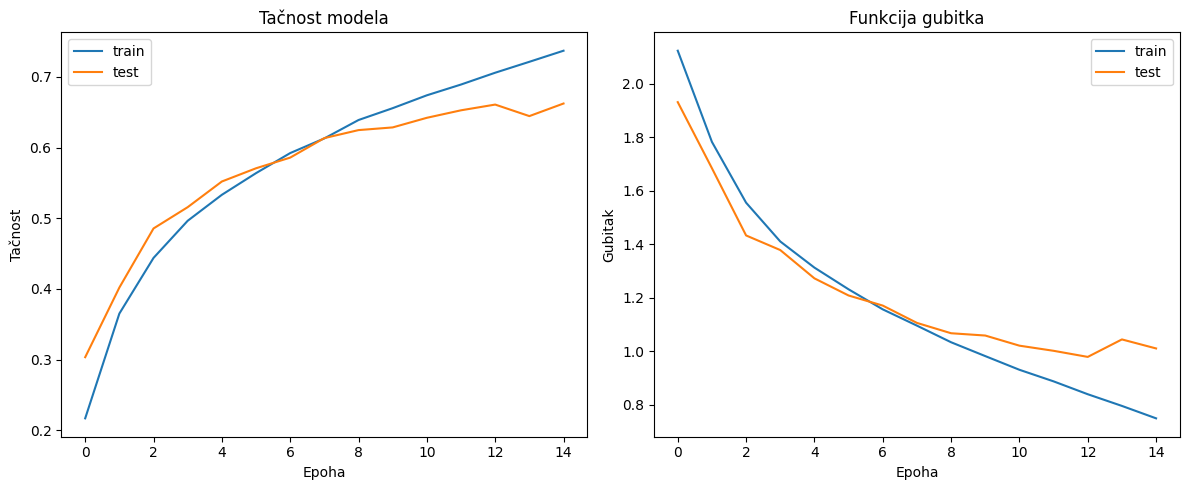

In [10]:
plt.figure(figsize=(12, 5))

# Plot za tačnost
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Tačnost modela')
plt.xlabel('Epoha')
plt.ylabel('Tačnost')
plt.legend()

# Plot za gubitak
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Funkcija gubitka')
plt.xlabel('Epoha')
plt.ylabel('Gubitak')
plt.legend()

plt.tight_layout()
plt.show()

# h) Dodavanje Dropout sloja


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1367 - loss: 2.2678 - val_accuracy: 0.3139 - val_loss: 1.9254
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3177 - loss: 1.8922 - val_accuracy: 0.4172 - val_loss: 1.6232
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4048 - loss: 1.6423 - val_accuracy: 0.4551 - val_loss: 1.4946
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4432 - loss: 1.5391 - val_accuracy: 0.4795 - val_loss: 1.4378
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4766 - loss: 1.4575 - val_accuracy: 0.5131 - val_loss: 1.3465
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5080 - loss: 1.3718 - val_accuracy: 0.5379 - val_loss: 1.2791
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5298 - loss: 1.3122 - val_accuracy: 0.5589 - val_loss: 1.2301
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5509 - loss: 1.2538 - val_accuracy: 0

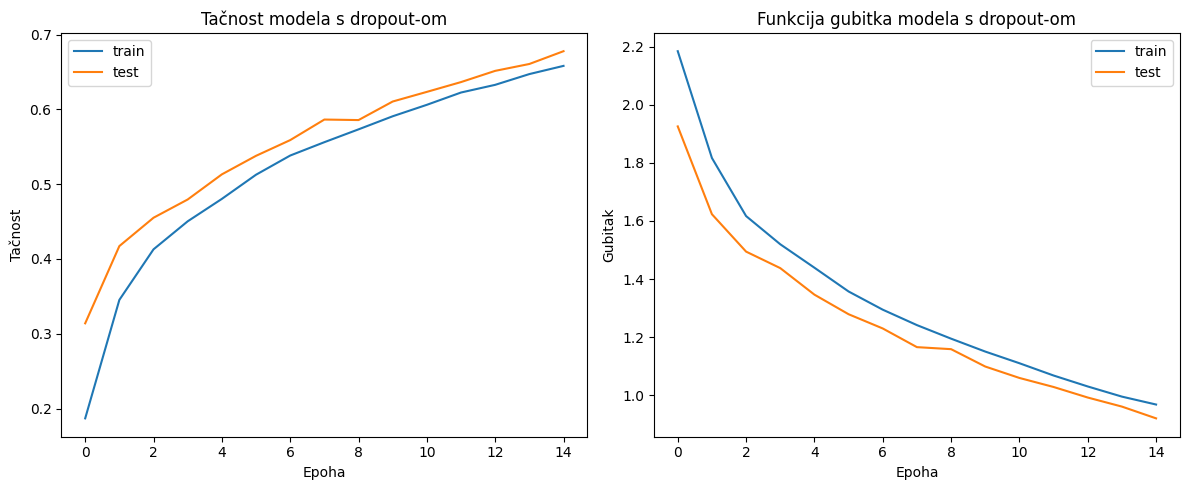

In [11]:
def define_model_with_dropout():
    model = Sequential()

    # Prvi blok konvolucionih slojeva
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    # Drugi blok konvolucionih slojeva
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))

    # Pretvaranje 2D podataka u 1D
    model.add(Flatten())

    # Dodavanje Dropout sloja
    model.add(Dropout(0.5))

    # Potpuno povezani slojevi
    model.add(Dense(128, activation='relu'))

    # Izlazni sloj
    model.add(Dense(10, activation='softmax'))

    # Kompajliranje modela
    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# Kreiranje modela s dropout-om
model_dropout = define_model_with_dropout()
model_dropout.summary()

# Treniranje i evaluacija modela
history_dropout = model_dropout.fit(
    trainX, trainY,
    epochs=15,
    batch_size=64,
    validation_data=(testX, testY),
    verbose=1
)

# Evaluacija modela
_, acc_dropout = model_dropout.evaluate(testX, testY, verbose=0)
print('Tačnost modela s dropout-om: %.3f' % (acc_dropout * 100.0))

# Plot ponašanja tačnosti i gubitka kroz epohe
plt.figure(figsize=(12, 5))

# Plot za tačnost
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['accuracy'], label='train')
plt.plot(history_dropout.history['val_accuracy'], label='test')
plt.title('Tačnost modela s dropout-om')
plt.xlabel('Epoha')
plt.ylabel('Tačnost')
plt.legend()

# Plot za gubitak
plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['loss'], label='train')
plt.plot(history_dropout.history['val_loss'], label='test')
plt.title('Funkcija gubitka modela s dropout-om')
plt.xlabel('Epoha')
plt.ylabel('Gubitak')
plt.legend()

plt.tight_layout()
plt.show()

# i) Kreiranje finalnog modela


In [12]:
def define_final_model():
    model = Sequential()

    # Prvi blok konvolucionih slojeva
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))

    # Drugi blok konvolucionih slojeva
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))

    # Treći blok konvolucionih slojeva
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2))

    # Pretvaranje 2D podataka u 1D
    model.add(Flatten())

    # Potpuno povezani slojevi
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.2))

    # Izlazni sloj
    model.add(Dense(10, activation='softmax'))

    # Kompajliranje modela
    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.1224 - loss: 2.2920 - val_accuracy: 0.2620 - val_loss: 2.0985
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2501 - loss: 2.0398 - val_accuracy: 0.3529 - val_loss: 1.8381
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3314 - loss: 1.8373 - val_accuracy: 0.4071 - val_loss: 1.6528
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3834 - loss: 1.6824 - val_accuracy: 0.4360 - val_loss: 1.5516
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4154 - loss: 1.6013 - val_accuracy: 0.4620 - val_loss: 1.4614
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4385 - loss: 1.5293 - val_accuracy: 0.4924 - val_loss: 1.3875
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4704 - loss: 1.4464 - val_accuracy: 0.5188 - val_loss: 1.3456
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4963 - loss: 1.3838 - val_accur

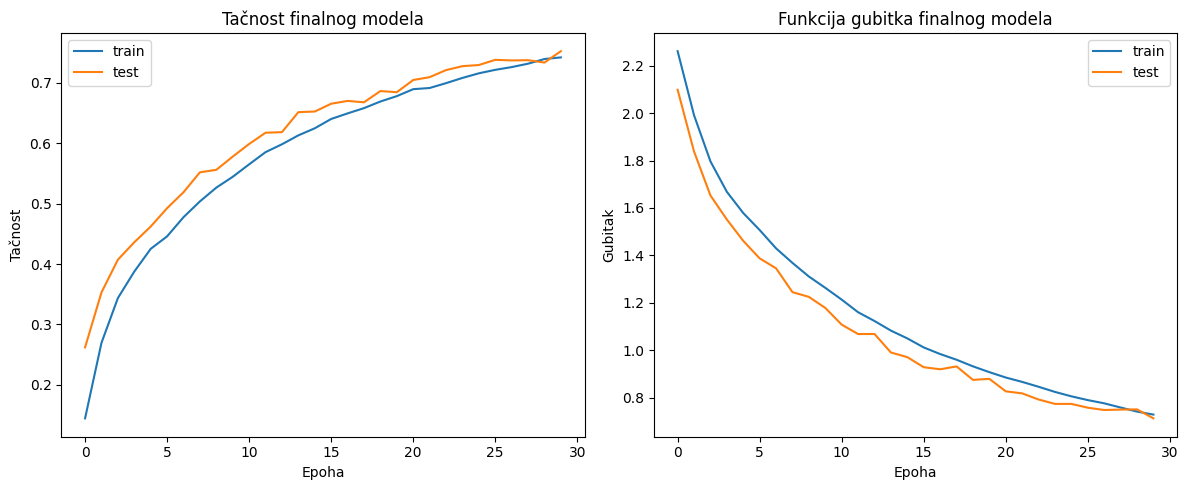

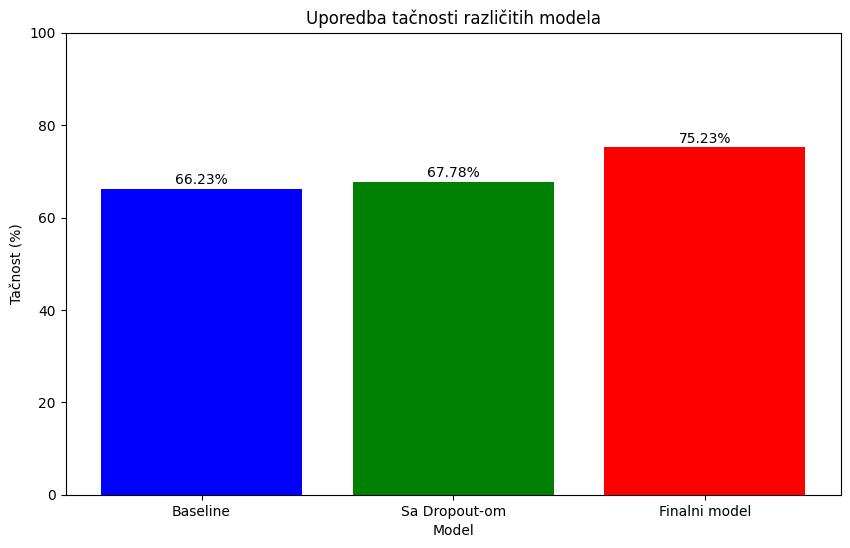

In [13]:
# Kreiranje finalnog modela
final_model = define_final_model()
final_model.summary()

# Treniranje i evaluacija finalnog modela
history_final = final_model.fit(
    trainX, trainY,
    epochs=30,
    batch_size=64,
    validation_data=(testX, testY),
    verbose=1
)

# Evaluacija finalnog modela
_, acc_final = final_model.evaluate(testX, testY, verbose=0)
print('Tačnost finalnog modela: %.3f' % (acc_final * 100.0))

# Plot ponašanja tačnosti i gubitka kroz epohe za finalni model
plt.figure(figsize=(12, 5))

# Plot za tačnost
plt.subplot(1, 2, 1)
plt.plot(history_final.history['accuracy'], label='train')
plt.plot(history_final.history['val_accuracy'], label='test')
plt.title('Tačnost finalnog modela')
plt.xlabel('Epoha')
plt.ylabel('Tačnost')
plt.legend()

# Plot za gubitak
plt.subplot(1, 2, 2)
plt.plot(history_final.history['loss'], label='train')
plt.plot(history_final.history['val_loss'], label='test')
plt.title('Funkcija gubitka finalnog modela')
plt.xlabel('Epoha')
plt.ylabel('Gubitak')
plt.legend()

plt.tight_layout()
plt.show()

# Uporedba svih modela
models = ['Baseline', 'Sa Dropout-om', 'Finalni model']
accuracies = [acc * 100.0, acc_dropout * 100.0, acc_final * 100.0]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red'])
plt.title('Uporedba tačnosti različitih modela')
plt.xlabel('Model')
plt.ylabel('Tačnost (%)')
plt.ylim([0, 100])
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.show()